# Tariff Pricing & Monitoring Agent

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"F:\EV_Tariff_Optimization\data\cleaned_acn_data.csv"
)

## Define Dynamic Pricing Strategy

In [2]:
hourly_kwh = df.groupby('hour')['kWhDelivered'].sum()

max_kwh = hourly_kwh.max()

utilization_ratio = hourly_kwh / max_kwh

dynamic_tariff = {}

for hour, ratio in utilization_ratio.items():

    if ratio > 0.8:
        dynamic_tariff[hour] = 25

    elif ratio < 0.3:
        dynamic_tariff[hour] = 10

    else:
        dynamic_tariff[hour] = 15

df['dynamic_tariff'] = df['hour'].map(dynamic_tariff)

## Fixed & Dynamic Revenue Calculation

In [8]:
df['fixed_revenue'] = df['kWhDelivered'] * 15

df['dynamic_revenue'] = (
    df['kWhDelivered']
    * df['dynamic_tariff']
)

fixed_total = df['fixed_revenue'].sum()

dynamic_total = df['dynamic_revenue'].sum()

## Revenue Gain Percentage

In [9]:
revenue_gain = (
    (dynamic_total - fixed_total)
    / fixed_total
) * 100

print("Revenue Gain %:", revenue_gain)

Revenue Gain %: 15.60835189047034


## Pricing Efficiency Score

In [4]:
pricing_efficiency = (
    dynamic_total
    / df['kWhDelivered'].sum()
)

print("Pricing Efficiency:", pricing_efficiency)

Pricing Efficiency: 17.341252783570553


In [5]:
df['peak_period'] = df['hour'].apply(
    lambda x: 'Peak'
    if 16 <= x <= 19
    else 'Off-Peak'
)

utilization_summary = (
    df.groupby('peak_period')
      ['kWhDelivered']
      .sum()
)

print(utilization_summary)

peak_period
Off-Peak    4947.166027
Peak        8628.060710
Name: kWhDelivered, dtype: float64


## Final ACN Performance Metrics

In [6]:
summary = pd.DataFrame({
    'Metric': [
        'Fixed Revenue',
        'Dynamic Revenue',
        'Revenue Gain %',
        'Pricing Efficiency'
    ],

    'Value': [
        fixed_total,
        dynamic_total,
        revenue_gain,
        pricing_efficiency
    ]
})
summary

,Metric,Value
0,Fixed Revenue,203628.401064
1,Dynamic Revenue,235411.438451
2,Revenue Gain %,15.608352
3,Pricing Efficiency,17.341253


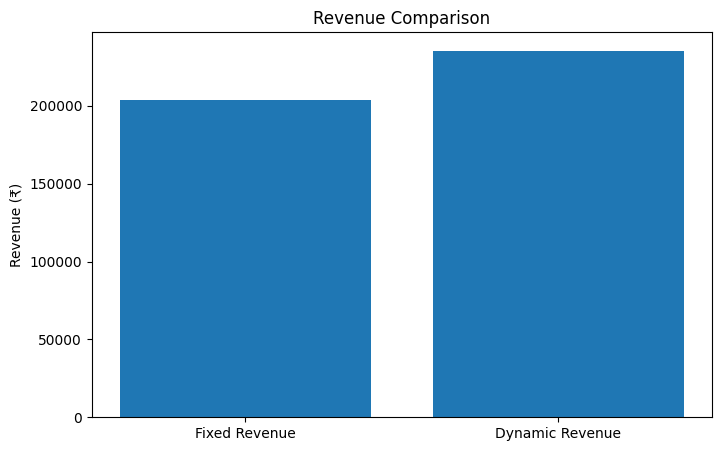

In [7]:
import matplotlib.pyplot as plt

comparison = {
    'Fixed Revenue': fixed_total,
    'Dynamic Revenue': dynamic_total
}

plt.figure(figsize=(8,5))

plt.bar(
    comparison.keys(),
    comparison.values()
)

plt.title("Revenue Comparison")

plt.ylabel("Revenue (₹)")

plt.show()